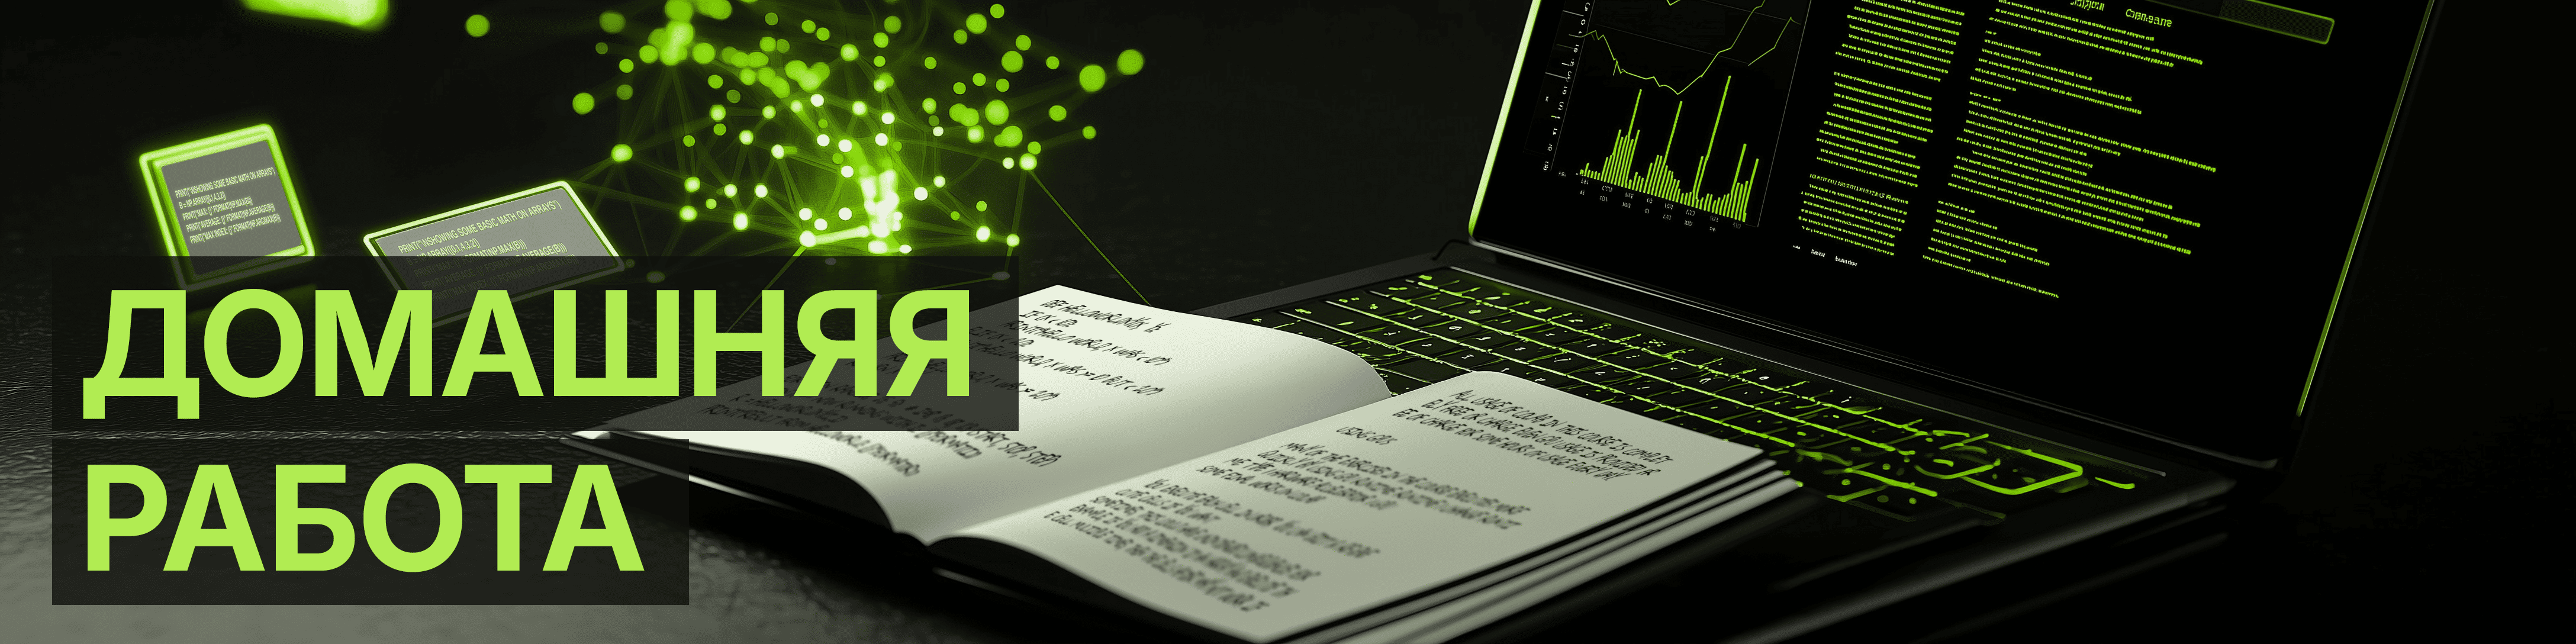

**Навигация по уроку**

1. [Анализ временных рядов с помощью НС](https://colab.research.google.com/drive/1q9nM-aWF6wZ2XuBxjQEAgjKxrL45axit)
2. [Сравнение архитектур нейронных сетей для обработки временных рядов](https://colab.research.google.com/drive/1-D-qXFYJ9b5sLLz_CFkUYmR-I2tM7KO2)
3. Домашняя работа

**В домашней работе вам необходимо:**
1. Выбрать любую понравившуюся модель из [практической](https://colab.research.google.com/drive/1-D-qXFYJ9b5sLLz_CFkUYmR-I2tM7KO2) части урока.
2. Используя известный [датасет](https://storage.yandexcloud.net/academy.ai/AAPL.csv) котировок Apple, обучить модель. Вывести графики из урока: график процесса обучения, сопоставления базового и прогнозного рядов, а также график автокорреляции.
3. Для получения трех проходных баллов за урок необходимо скорректировать код урока для данных с batch_size не равному 1.
4. Хотите 4 балла? Возьмите полносвязанную модель или с одномерной сверткой. Добейтесь подбором параметров и выбором архитектуры идеального графика автокорреляции без холмиков, равномерно спадающих графиков эталонной и прогнозной автокорреляции, максимально близко друг к другу.
5. Для получения дополнительного балла вам необходимо избавиться от тренда с помощью дифференцирования в датасете.
6. Еще один балл можно получить сверху, если догадаетесь как на графике сопоставления базового и прогнозного рядов отобразить реальную дату, а не относительную.

In [1]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Построение моделей нейронных сетей
from keras.models import Sequential, Model

# Слои
from keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization
from keras.layers import Flatten, Conv1D, Conv2D, LSTM, GlobalMaxPooling1D
from keras.layers import MaxPooling1D, RepeatVector

# Оптимизаторы
from keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировка
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Отрисовка графиков
import matplotlib.pyplot as plt
%matplotlib inline

# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

# Отключение лишних предупреждений
import warnings
warnings.filterwarnings('ignore')

In [2]:
# импортируем файл с данными о котировках акций Apple
!wget https://storage.yandexcloud.net/academy.ai/AAPL.csv

# Загрузим только необходимые колонки usecols, укажем, что колонку Date необходимо преобразовать в формат DateTime (parse_dates) и сделать индексом index_col
price = pd.read_csv("./AAPL.csv", index_col='Date', usecols = ['Adj Close', 'Volume', 'Date'], parse_dates=['Date'])
price.head()

--2025-10-13 10:18:19--  https://storage.yandexcloud.net/academy.ai/AAPL.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 186539 (182K) [text/csv]
Saving to: ‘AAPL.csv’

AAPL.csv            100%[===================>] 182.17K   333KB/s    in 0.5s    

2025-10-13 10:18:21 (333 KB/s) - ‘AAPL.csv’ saved [186539/186539]



,Adj Close,Volume
Date,,
2014-01-02,17.296652,234684800
2014-01-03,16.916719,392467600
2014-01-06,17.008968,412610800
2014-01-07,16.887323,317209200
2014-01-08,16.994270,258529600


In [3]:
price.drop(columns=['Volume'], inplace=True)

In [4]:
train_data = price[:'2023-01-10']
test_data = price['2023-01-20':]

In [5]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

In [6]:
# Проверка формы данных
print(f'Тренировочные данные: {scaled_train_data.shape}')
print(f'Тестовые данные: {scaled_test_data.shape}')

Тренировочные данные: (2272, 1)
Тестовые данные: (299, 1)


In [7]:
n_input = 14  # Размерность входных данных
n_features = 1 # Размерность выходных данных
BATCH_SIZE = 32 # Размер пакета

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма обучающего пакета: {generator[0][0].shape}, y: {generator[0][1].shape}')

Форма обучающего пакета: (32, 14, 1), y: (32, 1)


In [8]:
validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма валидационного пакета: {validator[0][0].shape}, y: {validator[0][1].shape}')

Форма валидационного пакета: (32, 14, 1), y: (32, 1)


In [9]:
tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=scaled_test_data.shape[0])
x_test, y_test = tester[0]
print(f'Форма тестовой выборки: {x_test.shape}, y: {y_test.shape}')

Форма тестовой выборки: (285, 14, 1), y: (285, 1)


In [10]:
# Объявление функции графика обучения
def history_plot(history, title):

    # Рисование графиков обучения
    fig = plt.figure(figsize=(14, 7))
    plt.plot(history.history['loss'], label='Ошибка на обучающем наборе')
    plt.plot(history.history['val_loss'], label='Ошибка на проверочном наборе')
    plt.title(f'{title}. График обучения')

    # Показываем только целые метки шкалы оси x
    fig.gca().xaxis.get_major_locator().set_params(integer=True)
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Средняя ошибка')
    plt.legend()
    plt.show()

# Функция расчета корреляции для двух рядов
def correlate(a, b):
    return np.corrcoef(a, b)[0, 1]

# Функция визуализации результата предсказания сети и верных ответов

def show_predict(y_pred, y_true, title=''):
    fig = plt.figure(figsize=(14, 7))
    # Прогнозный ряд сдвигается на 1 шаг назад, так как предсказание делалось на 1 шаг вперед
    plt.plot(y_pred[1:], label=f'Прогноз')
    plt.plot(y_true[:-1], label=f'Базовый')
    plt.title(title)

    # Показываем только целые метки шкалы оси x
    fig.gca().xaxis.get_major_locator().set_params(integer=True)
    plt.xlabel('Дата (относительно начала выборки)')
    plt.ylabel('Значение')
    plt.legend()
    plt.show()

# Функция расчета результата предсказания
def get_pred(model, # модель
             x_test, y_test, # тестовая выборка
             y_scaler): # масштабирующий объект для y

    # Вычисление и деномализация предсказания
    y_pred_unscaled = y_scaler.inverse_transform(model.predict(x_test, verbose=0))

    # Денормализация верных ответов
    y_test_unscaled = y_scaler.inverse_transform(y_test)

    # Возврат результата предсказания и верные ответы в исходном масштабе
    return y_pred_unscaled, y_test_unscaled

# Функция рисования корреляций прогнозного ряда и исходного со смещением
# break_step - ограничитель на число временных лагов

def show_corr(y_pred, y_true, title='', break_step=30):

    # выбираем наименьшее из длины y_len и break_step в качестве числа лагов для графика
    y_len = y_true.shape[0]
    steps = range(1, np.min([y_len+1, break_step+1]))

    # Вычисление коэффициентов корреляции базового ряда и предсказания с разным смещением
    cross_corr = [correlate(y_true[:-step, 0], y_pred[step:, 0]) for step in steps]

    # Вычисление коэффициентов автокорреляции базового ряда с разным смещением
    auto_corr = [correlate(y_true[:-step, 0], y_true[step:, 0]) for step in steps]

    plt.plot(steps, cross_corr, label=f'Прогноз')
    plt.plot(steps, auto_corr, label=f'Эталон')

    plt.title(title)

    # Назначение меток шкалы оси x
    plt.xticks(steps)
    plt.xlabel('Шаги смещения')
    plt.ylabel('Коэффициент корреляции')
    plt.legend()
    plt.show()

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout


model_dense = Sequential()
model_dense.add(Dense(256, input_shape=generator[0][0].shape[1:],
                     activation='relu'))
model_dense.add(Dropout(0.2))  # Регуляризация после первого слоя
model_dense.add(Dense(128, activation='relu'))  # Добавленный слой
#model_dense.add(Dropout(0.1))  # Регуляризация после второго слоя
model_dense.add(Dense(64, activation='relu'))
model_dense.add(Dense(32, activation='relu'))
model_dense.add(Dense(16, activation='relu'))
model_dense.add(Flatten())
model_dense.add(Dense(n_features, activation='linear'))
model_dense.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

model_dense.summary()


early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14, 256)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14, 16)         │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,497 (173.82 KB)

 Trainable params: 44,497 (173.82 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model_dense.fit(generator, epochs=1000, validation_data=validator,
                   callbacks=[early_stop, checkpoint], verbose=1)

Epoch 1/1000
69/71 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1369

71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.1338 - val_loss: 0.0020
Epoch 2/1000
67/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0016
Epoch 3/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7816e-04 - val_loss: 0.0076
Epoch 4/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - val_loss: 0.0046
Epoch 5/1000
68/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 6/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.3839e-04 - val_loss: 0.0023
Epoch 7/1000
61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.8258e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.1661e-04 - val_loss: 0.0013
Epoch 8/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.8044e-04 - val_loss: 0.0023
Epoch 9/1000
68/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011    

...

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.2395e-04 - val_loss: 2.4955e-04
Epoch 450/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1372e-04 - val_loss: 4.7398e-04
Epoch 451/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2068e-04 - val_loss: 0.0011
Epoch 452/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - val_loss: 7.1993e-04
Epoch 453/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.8895e-04 - val_loss: 2.7375e-04
Epoch 454/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7833e-04 - val_loss: 3.7668e-04
Epoch 455/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3135e-04 - val_loss: 3.8095e-04
Epoch 456/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0854e-04 - val_loss: 2.6630e-04
Epoch 457/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3430e-04 - val_loss: 2.8883e-04
Epoch 458/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3019e-04 - val_loss: 0.0013
Epoch 459/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.418

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8072e-04 - val_loss: 2.4186e-04
Epoch 514/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6015e-04 - val_loss: 9.0710e-04
Epoch 515/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3047e-04 - val_loss: 2.4751e-04
Epoch 516/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9296e-04 - val_loss: 4.0089e-04
Epoch 517/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5686e-04 - val_loss: 4.4784e-04
Epoch 518/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1362e-04 - val_loss: 7.4331e-04
Epoch 519/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5844e-04 - val_loss: 4.0027e-04
Epoch 520/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2801e-04 - val_loss: 0.0013
Epoch 521/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9744e-04 - val_loss: 2.4797e-04
Epoch 522/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5044e-04 - val_loss: 3.0054e-04
Epoch 523/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - los

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7852e-04 - val_loss: 2.3490e-04
Epoch 539/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8258e-04 - val_loss: 0.0012
Epoch 540/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3553e-04 - val_loss: 3.9084e-04
Epoch 541/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0319e-04 - val_loss: 3.9325e-04
Epoch 542/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7765e-04 - val_loss: 2.4733e-04
Epoch 543/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8450e-04 - val_loss: 7.9743e-04
Epoch 544/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5507e-04 - val_loss: 3.7697e-04
Epoch 545/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5305e-04 - val_loss: 5.6595e-04
Epoch 546/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1002e-04 - val_loss: 4.5081e-04
Epoch 547/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1818e-04 - val_loss: 3.2786e-04
Epoch 548/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - los

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.9465e-04 - val_loss: 2.3425e-04
Epoch 551/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7158e-04 - val_loss: 6.1542e-04
Epoch 552/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1600e-04 - val_loss: 0.0024
Epoch 553/1000
57/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2317e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2403e-04 - val_loss: 2.2808e-04
Epoch 554/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9321e-04 - val_loss: 3.6071e-04
Epoch 555/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.3122e-04 - val_loss: 2.3198e-04
Epoch 556/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6990e-04 - val_loss: 9.2484e-04
Epoch 557/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6188e-04 - val_loss: 0.0011
Epoch 558/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0316e-04 - val_loss: 0.0038
Epoch 559/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7.4986e-04 - val_loss: 9.2781e-04
Epoch 560/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9066e-04 - val_loss: 6.2593e-04
Epoch 561/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3043e-04 - val_loss: 8.8697e-04
Epoch 562/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2762e-04 - val_loss: 0.0031
Epoch 563/1000
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.622

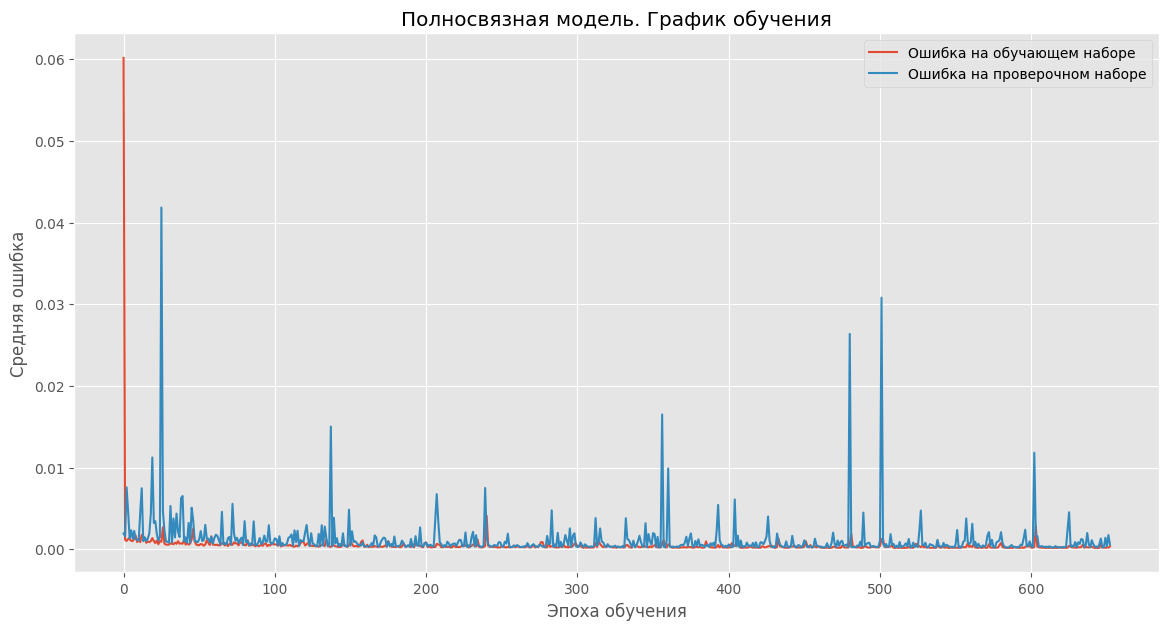

In [13]:
history_plot(model_dense.history, 'Полносвязная модель')

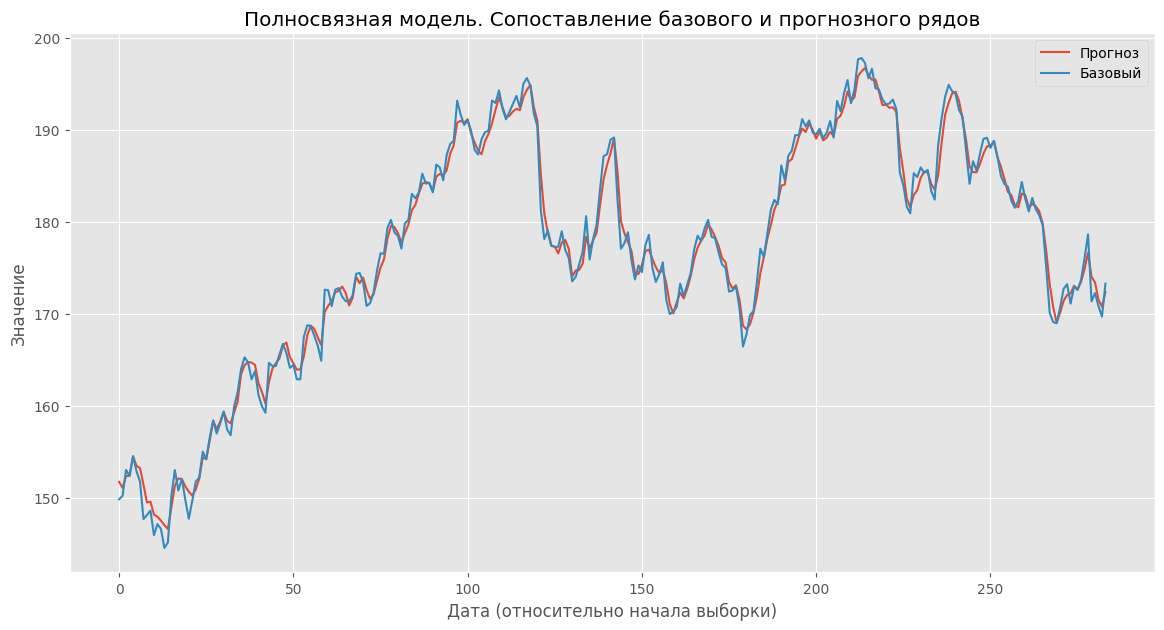

In [14]:
# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model_dense, x_test, y_test, scaler)

# Отрисовка графика сопоставления базового и прогнозного рядов
show_predict(y_pred, y_true, title=f'Полносвязная модель. Сопоставление базового и прогнозного рядов')



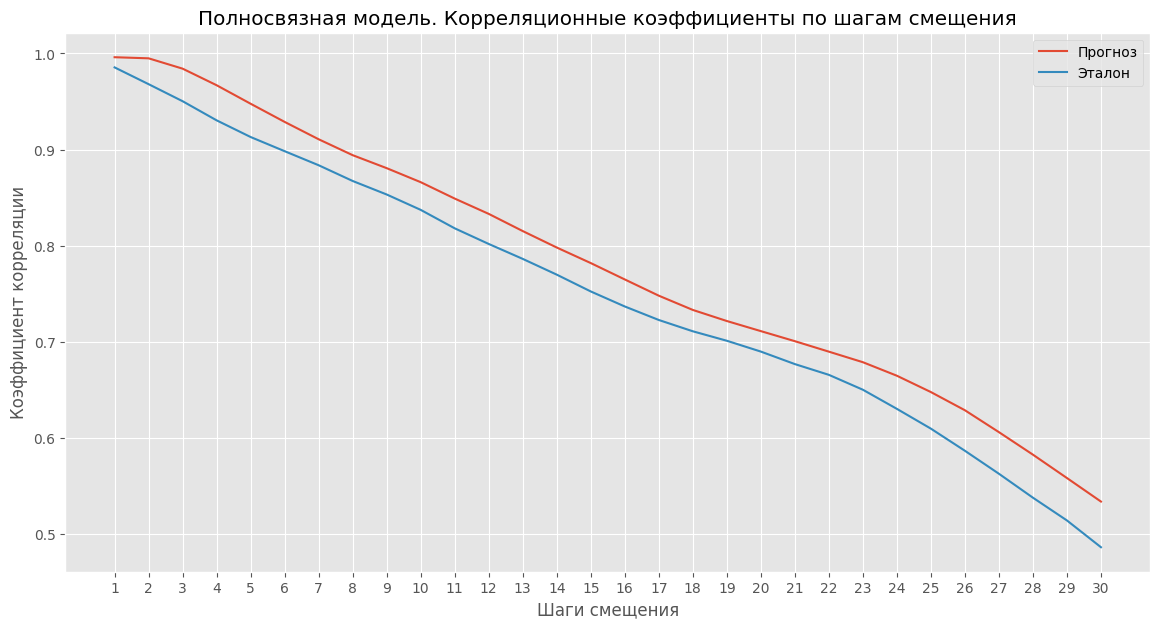

In [15]:
# Отрисовка графика корреляционных коэффициентов до заданного максимума шагов смещения
show_corr(y_pred, y_true, title=f'Полносвязная модель. Корреляционные коэффициенты по шагам смещения')

In [16]:
price_diff = price.diff().dropna()

In [19]:
train_data = price_diff[:'2023-01-10']
test_data = price_diff['2023-01-20':]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_data)
scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

n_input = 14  # Размерность входных данных
n_features = 1 # Размерность выходных данных
BATCH_SIZE = 8 # Размер пакета

generator = TimeseriesGenerator(scaled_train_data, scaled_train_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма обучающего пакета: {generator[0][0].shape}, y: {generator[0][1].shape}')

validator = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=BATCH_SIZE)
print(f'Форма валидационного пакета: {validator[0][0].shape}, y: {validator[0][1].shape}')

tester = TimeseriesGenerator(scaled_test_data, scaled_test_data, length=n_input, batch_size=scaled_test_data.shape[0])
x_test, y_test = tester[0]
print(f'Форма тестовой выборки: {x_test.shape}, y: {y_test.shape}')


Форма обучающего пакета: (8, 14, 1), y: (8, 1)
Форма валидационного пакета: (8, 14, 1), y: (8, 1)
Форма тестовой выборки: (285, 14, 1), y: (285, 1)


In [20]:
model_dense = Sequential()
model_dense.add(Dense(256, input_shape=generator[0][0].shape[1:],
                     activation='relu'))
model_dense.add(Dropout(0.2))  # Регуляризация после первого слоя
model_dense.add(Dense(128, activation='relu'))  # Добавленный слой
#model_dense.add(Dropout(0.1))  # Регуляризация после второго слоя
model_dense.add(Dense(64, activation='relu'))
model_dense.add(Dense(32, activation='relu'))
model_dense.add(Dense(16, activation='relu'))
model_dense.add(Flatten())
model_dense.add(Dense(n_features, activation='linear'))
model_dense.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

model_dense.summary()


early_stop = EarlyStopping(monitor='val_loss', patience=100, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 14, 256)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 14, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 14, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 14, 32)         │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 14, 16)         │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,497 (173.82 KB)

 Trainable params: 44,497 (173.82 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_dense.fit(generator, epochs=1000, validation_data=validator,
                   callbacks=[early_stop, checkpoint], verbose=1)

Epoch 1/1000
264/283 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0334

283/283 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0320 - val_loss: 0.0108
Epoch 2/1000
264/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - val_loss: 0.0104
Epoch 3/1000
280/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0065

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0099
Epoch 4/1000
267/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0053

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0053 - val_loss: 0.0099
Epoch 5/1000
278/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061

...

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - val_loss: 0.0096
Epoch 13/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0096
Epoch 14/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0060 - val_loss: 0.0105
Epoch 15/1000
282/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0049

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0049 - val_loss: 0.0096
Epoch 16/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0101
Epoch 17/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062 - val_loss: 0.0098
Epoch 18/1000
279/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0060

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - val_loss: 0.0096
Epoch 19/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047 - val_loss: 0.0097
Epoch 20/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - val_loss: 0.0096
Epoch 21/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0061 - val_loss: 0.0097
Epoch 22/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0098
Epoch 23/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0067 - val_loss: 0.0097
Epoch 24/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053 - val_loss: 0.0099
Epoch 25/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056 - val_loss: 0.0096
Epoch 26/1000
277/283 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0054

283/283 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0054 - val_loss: 0.0096
Epoch 27/1000
267/283 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0058

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - val_loss: 0.0096
Epoch 28/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - val_loss: 0.0101
Epoch 29/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0053 - val_loss: 0.0102
Epoch 30/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - val_loss: 0.0096
Epoch 31/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0048 - val_loss: 0.0097
Epoch 32/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - val_loss: 0.0097
Epoch 33/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0062 - val_loss: 0.0099
Epoch 34/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057 - val_loss: 0.0096
Epoch 35/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052 - val_loss: 0.0096
Epoch 36/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0066 - val_loss: 0.0100
Epoch 37/1000
283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0056 - val_loss: 0.0097
Epoch 38/1000
283/283 ━━━━━━━━━━━━━

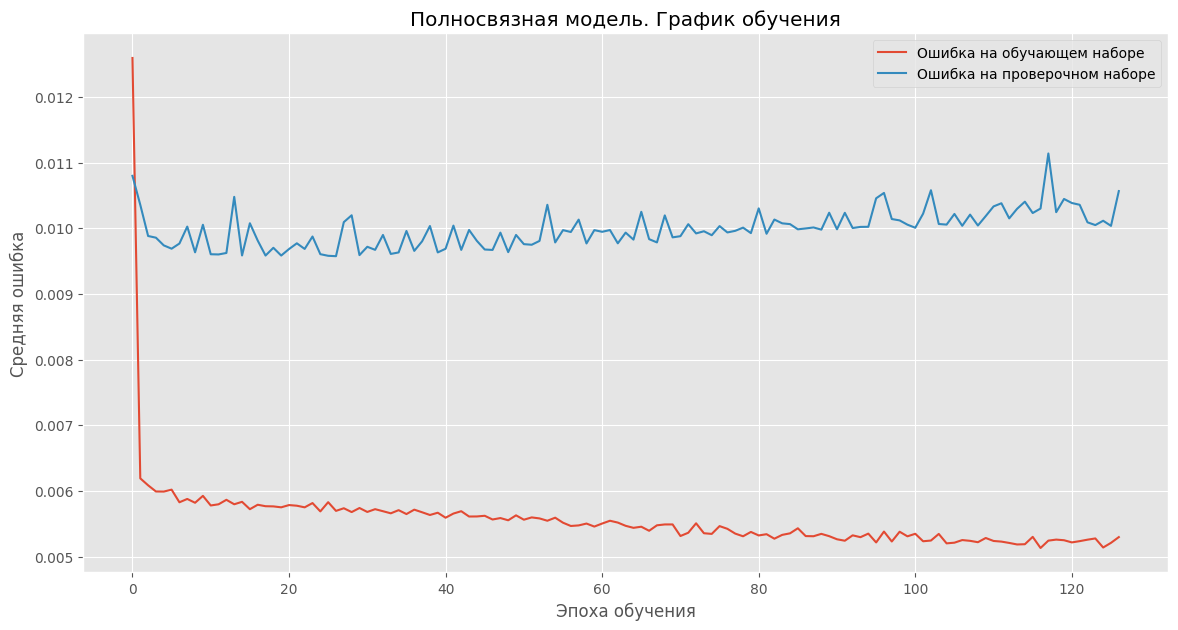

In [22]:
history_plot(model_dense.history, 'Полносвязная модель')

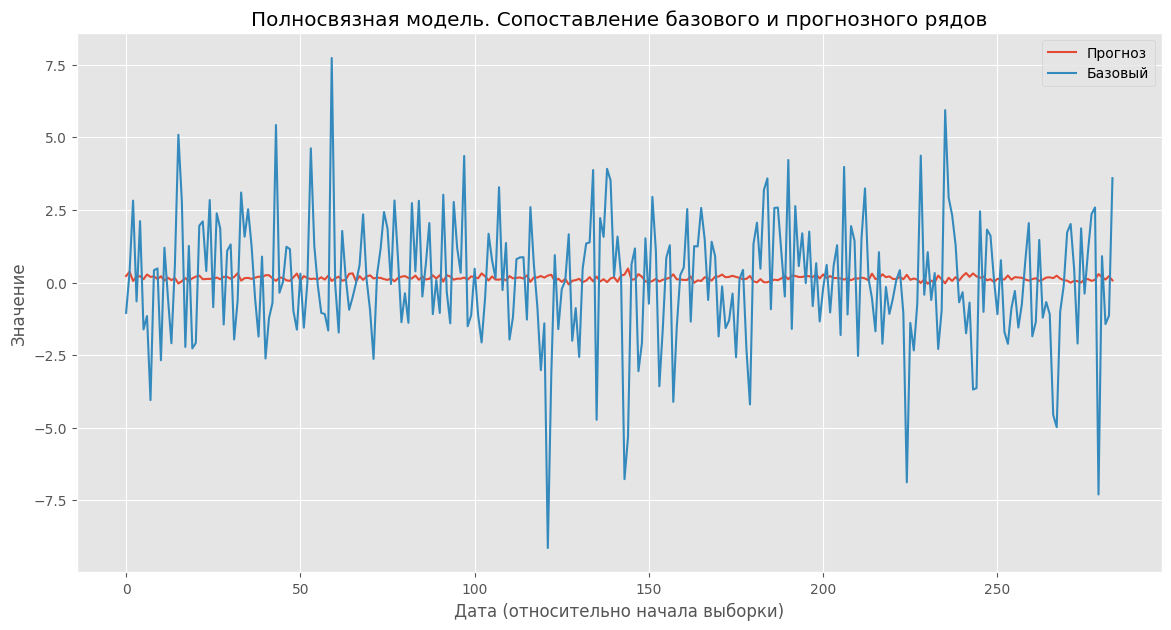

In [23]:
# Получение денормализованного предсказания и данных базового ряда
y_pred, y_true = get_pred(model_dense, x_test, y_test, scaler)

# Отрисовка графика сопоставления базового и прогнозного рядов
show_predict(y_pred, y_true, title=f'Полносвязная модель. Сопоставление базового и прогнозного рядов')



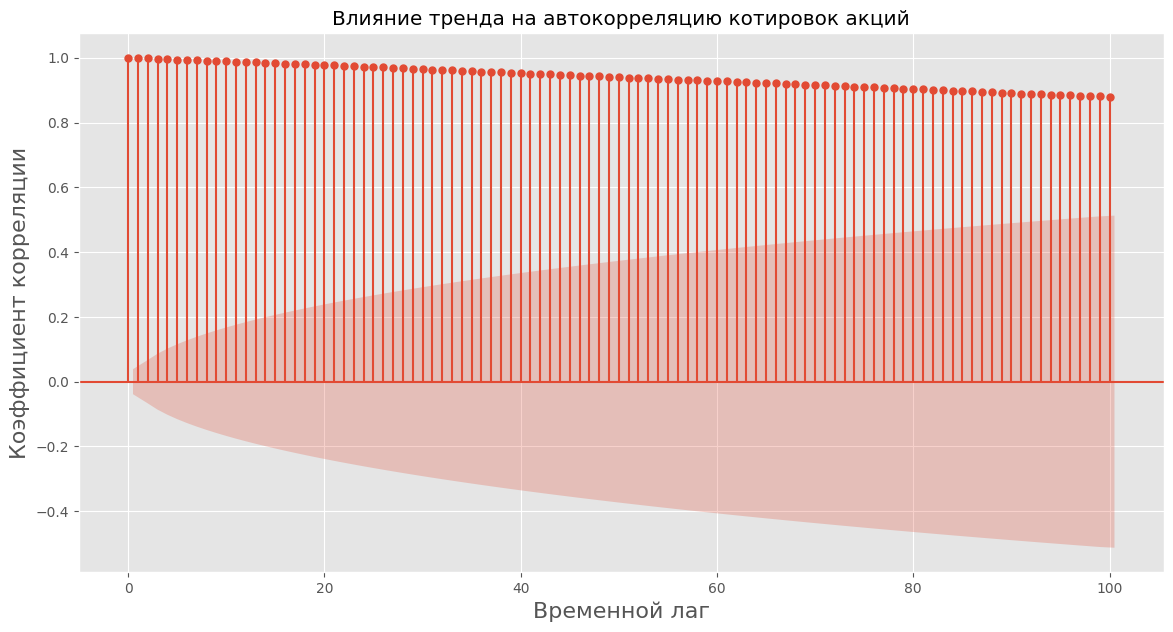

In [24]:
# импортируем автокорреляционную функцию (ACF)
from statsmodels.graphics.tsaplots import plot_acf

# применим функцию к нашему набору данных
# параметр lags - сколько мы хотим отобразить лагов
plot_acf(price['Adj Close'], lags = 100)

# добавим отступы сверху и снизу на графике
plt.axis('tight')
plt.title('Влияние тренда на автокорреляцию котировок акций')
plt.xlabel('Временной лаг', fontsize = 16)
plt.ylabel('Коэффициент корреляции', fontsize = 16)
plt.show()

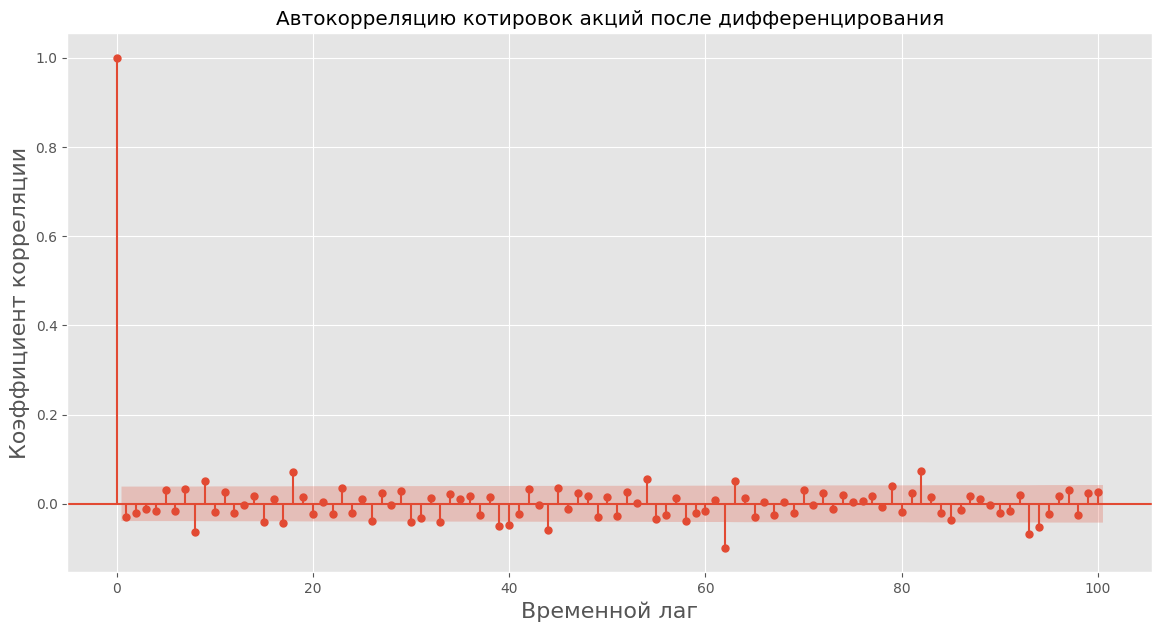

In [25]:
# импортируем автокорреляционную функцию (ACF)
from statsmodels.graphics.tsaplots import plot_acf

# применим функцию к нашему набору данных
# параметр lags - сколько мы хотим отобразить лагов
plot_acf(price_diff, lags = 100)

# добавим отступы сверху и снизу на графике
plt.axis('tight')
plt.title('Автокорреляцию котировок акций после дифференцирования')
plt.xlabel('Временной лаг', fontsize = 16)
plt.ylabel('Коэффициент корреляции', fontsize = 16)
plt.show()